In [1562]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

In [1563]:
import warnings
warnings.filterwarnings('ignore')

# LOAD DATA

In [1564]:
import pandas as pd

df = pd.read_csv("/content/Credis_Score_Dataset_A.csv")
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x113fb,CUS_0x78af,February,Greg Roumeliotisg,36,365-11-8309,Teacher,88827.54000000002,7199.295000,5,...,Standard,512.09,27.652902,11 Years and 3 Months,Yes,277.043609,135.02877621323586,!@9#%8,567.8571148175499,Standard
1,0x23e41,CUS_0x7d8,April,Ayla Jeany,14_,680-85-5010,Doctor,19288.47_,1408.372500,10,...,Bad,1873.07,28.477331,5 Years and 7 Months,Yes,49.388699,176.92086141687474,Low_spent_Small_value_payments,204.52768958953004,Poor
2,0x20142,CUS_0x39d4,January,Debra Shermanh,45,034-42-6069,Accountant,73507.4,6146.616667,8,...,Bad,1660.98,24.865827,15 Years and 7 Months,Yes,412.051367,186.58955671354923,High_spent_Medium_value_payments,266.02074289372644,Poor
3,0xd194,CUS_0x8ac8,July,Steve Schererz,22,751-26-7144,Teacher,10037.735,871.477917,8,...,Bad,3052.44,33.704571,8 Years and 1 Months,Yes,36.667662,16.69811395620942,High_spent_Medium_value_payments,283.7820159487275,Standard
4,0x64dc,CUS_0x6734,March,Lefterisi,19,276-02-5954,_______,30922.5,2477.875000,8,...,Bad,4742.53,30.643675,1 Years and 0 Months,Yes,165.891821,218.49777601292416,Low_spent_Small_value_payments,153.39790325798555,Standard


In [1565]:
df.shape[0] # jumlah baris

50000

In [1566]:
df.shape[1] # jumlah kolom

28

In [1567]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        50000 non-null  object 
 1   Customer_ID               50000 non-null  object 
 2   Month                     50000 non-null  object 
 3   Name                      44957 non-null  object 
 4   Age                       50000 non-null  object 
 5   SSN                       50000 non-null  object 
 6   Occupation                50000 non-null  object 
 7   Annual_Income             50000 non-null  object 
 8   Monthly_Inhand_Salary     42486 non-null  float64
 9   Num_Bank_Accounts         50000 non-null  int64  
 10  Num_Credit_Card           50000 non-null  int64  
 11  Interest_Rate             50000 non-null  int64  
 12  Num_of_Loan               50000 non-null  object 
 13  Type_of_Loan              44268 non-null  object 
 14  Delay_

In [1568]:
df['Credit_Score'].value_counts()

,count
Credit_Score,
Standard,26587
Poor,14499
Good,8914


# EDA

## Inkosistensi handling dan Casting Type kolom Num_of_Delayed_Payment

In [1569]:
df['Num_of_Delayed_Payment'] = (
    df['Num_of_Delayed_Payment']
    .astype(str)
    .str.replace(r'[^0-9]', '', regex=True)
)

In [1570]:
df['Num_of_Delayed_Payment'].replace('', np.nan, inplace=True)

In [1571]:
df['Num_of_Delayed_Payment'] = df['Num_of_Delayed_Payment'].astype(float)

## Inkosistensi handling dan Casting Type kolom  Amount_invested_monthly



In [1572]:
df['Amount_invested_monthly'].describe()

,Amount_invested_monthly
count,47748
unique,45475
top,__10000__
freq,2179


In [1573]:
import numpy as np
import pandas as pd

df['Amount_invested_monthly'] = (
    df['Amount_invested_monthly']
    .astype(str)
    .str.replace('_', '', regex=False)
)

df['Amount_invested_monthly'] = pd.to_numeric(
    df['Amount_invested_monthly'],
    errors='coerce'
)

In [1574]:
df['Amount_invested_monthly']

,Amount_invested_monthly
0,135.028776
1,176.920861
2,186.589557
3,16.698114
4,218.497776
...,...
49995,27.096894
49996,139.420847
49997,47.019212
49998,53.477290


In [1575]:
df['Amount_invested_monthly'].describe()

,Amount_invested_monthly
count,47748.000000
mean,642.651730
std,2055.436780
min,0.000000
25%,74.578272
50%,135.576974
75%,266.020406
max,10000.000000


## Inkosistensi handling dan Casting Type kolom  Monthly_Balance



In [1576]:
import pandas as pd

df['Monthly_Balance'] = pd.to_numeric(
    df['Monthly_Balance'],
    errors='coerce'
)

In [1577]:
df['Monthly_Balance'].describe()

,Monthly_Balance
count,49406.000000
mean,402.270537
std,214.236411
min,0.095482
25%,270.360451
50%,336.061466
75%,470.400912
max,1602.040519


## Inkosistensi Kolom Credit_History_Age dengan mengubah satuannya.


In [1578]:
df['Credit_History_Age'].value_counts()

,count
Credit_History_Age,
15 Years and 11 Months,233
17 Years and 11 Months,233
19 Years and 5 Months,226
17 Years and 9 Months,226
15 Years and 9 Months,223
...,...
0 Years and 2 Months,9
0 Years and 3 Months,9
33 Years and 7 Months,4


agar kolom lebih mudah diinterpretasikan dan tidak menyebabkan inkosistensi data, saya akan melakukan perubahan satuan. Saya akan menyamakan semua variabel dalam ukuran bulan.

In [1579]:
import re

def credit_age_to_months(x):
    if pd.isna(x):
        return None
    years = int(re.search(r'(\d+)\s+Years?', x).group(1))
    months = int(re.search(r'(\d+)\s+Months?', x).group(1))
    return years * 12 + months

df['Credit_History_Age_Months'] = df['Credit_History_Age'].apply(credit_age_to_months)


In [1580]:
df['Credit_History_Age_Months'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 50000 entries, 0 to 49999
Series name: Credit_History_Age_Months
Non-Null Count  Dtype  
--------------  -----  
45434 non-null  float64
dtypes: float64(1)
memory usage: 390.8 KB


In [1581]:
# List kolom yang menurut analisis saya tidak relevan (irrelevant)
cols_to_drop = [
    'ID',
    'Customer_ID',
    'Name',
    'SSN',
    'Month',
    'Credit_History_Age' # dihapus karena sudah diperbarui
]

# Eksekusi drop
df = df.drop(columns=cols_to_drop)

print(f"Jumlah kolom awal: {df.shape[1]}")
print(f"Jumlah kolom setelah di-drop: {df_model.shape[1]}")

Jumlah kolom awal: 23
Jumlah kolom setelah di-drop: 23


## duplicated handling

In [1582]:
df.duplicated().sum()

np.int64(0)

there is no duplicated in this dataset so we can go to the next step.

## missing value

In [1583]:
df.isna().sum()

,0
Age,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,7514
Num_Bank_Accounts,0
Num_Credit_Card,0
Interest_Rate,0
Num_of_Loan,0
Type_of_Loan,5732
Delay_from_due_date,0


In [1584]:
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100
print(pd.concat([missing_data, missing_percentage], axis=1, keys=['Total Missing Value', 'Percent']))

                           Total Missing Value  Percent
Age                                          0    0.000
Occupation                                   0    0.000
Annual_Income                                0    0.000
Monthly_Inhand_Salary                     7514   15.028
Num_Bank_Accounts                            0    0.000
Num_Credit_Card                              0    0.000
Interest_Rate                                0    0.000
Num_of_Loan                                  0    0.000
Type_of_Loan                              5732   11.464
Delay_from_due_date                          0    0.000
Num_of_Delayed_Payment                    3400    6.800
Changed_Credit_Limit                         0    0.000
Num_Credit_Inquiries                       958    1.916
Credit_Mix                                   0    0.000
Outstanding_Debt                             0    0.000
Credit_Utilization_Ratio                     0    0.000
Payment_of_Min_Amount                        0  

### numerical checks

Jika ada skew, impute menggunakan median. Jika tidak memiliki skew, maka diimpute menggunakan mean.



```
# > 0.5 right skewed
# < 0.5 left skewed
```



In [1585]:
numerical_cols = df.select_dtypes(include=np.number).columns
df[numerical_cols].skew()

,0
Monthly_Inhand_Salary,1.135093
Num_Bank_Accounts,11.186785
Num_Credit_Card,8.608742
Interest_Rate,9.155130
Delay_from_due_date,0.957766
Num_of_Delayed_Payment,14.102335
Num_Credit_Inquiries,9.793486
Credit_Utilization_Ratio,0.029055
Total_EMI_per_month,7.133244
Amount_invested_monthly,4.292538


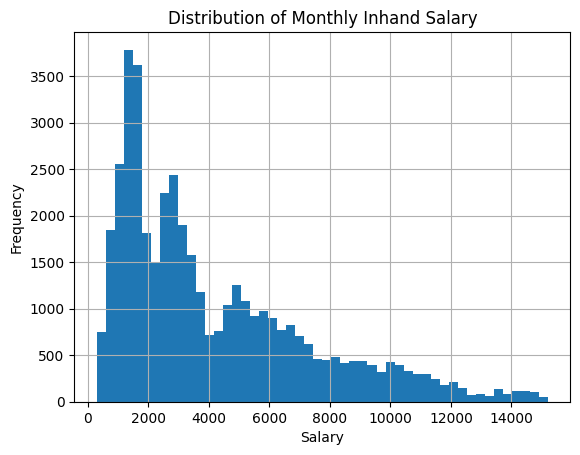

In [1586]:
import matplotlib.pyplot as plt

df['Monthly_Inhand_Salary'].hist(bins=50)
plt.title('Distribution of Monthly Inhand Salary')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.show()

dari sini kita bisa melihat bahwa 'Monthly_Inhand_Salary' adalah right skew distributed. Maka dari itu, saya memutuskan untuk melakukan impute UNKNOWN VALUE dari kolom ini menggunakan median

In [1587]:
median_salary = df['Monthly_Inhand_Salary'].median()

df['Monthly_Inhand_Salary'] = df['Monthly_Inhand_Salary'].fillna(median_salary)

In [1588]:
df['Num_of_Delayed_Payment'].skew()

np.float64(14.102335171020645)

Karena Num_of_Delayed_Payment adalah right skewed, maka impute menggunakan median

In [1589]:
Median_of_Delayed_Payment  = df['Num_of_Delayed_Payment'].median()

df['Num_of_Delayed_Payment'] = df['Num_of_Delayed_Payment'].fillna(Median_of_Delayed_Payment)

In [1590]:
df['Num_Credit_Inquiries'].skew()

np.float64(9.793486300350576)

In [1591]:
# karena right skewed, maka impute dengan median

Median_of_Credit_Inquiries  = df['Num_Credit_Inquiries'].median()
df['Num_Credit_Inquiries'] = df['Num_Credit_Inquiries'].fillna(Median_of_Credit_Inquiries)

In [1592]:
df['Amount_invested_monthly'].skew()

np.float64(4.29253792477075)

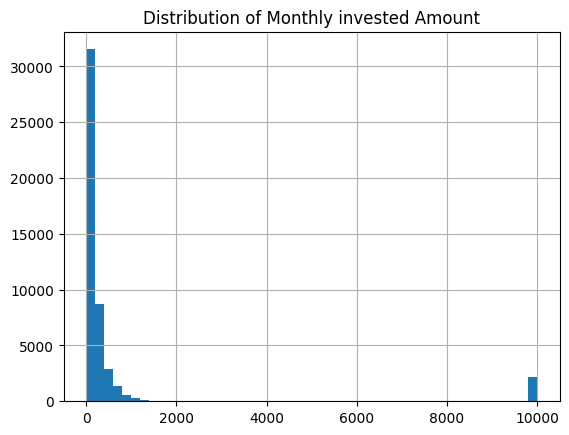

In [1593]:
import matplotlib.pyplot as plt

df['Amount_invested_monthly'].hist(bins=50)
plt.title('Distribution of Monthly invested Amount')
plt.show()

In [1594]:
# memiliki right skewed, maka diimpute menggunakan median

median_Amount_invested_monthly = df['Amount_invested_monthly'].median()
df['Amount_invested_monthly'] = df['Amount_invested_monthly'].fillna(median_Amount_invested_monthly)

In [1595]:
df['Monthly_Balance'].skew() # memiliki

np.float64(1.611833415618884)

In [1596]:
median_balance = df['Monthly_Balance'].median()
df['Monthly_Balance'] = df['Monthly_Balance'].fillna(median_balance)

In [1597]:
df['Credit_History_Age_Months'].skew()

np.float64(-0.04608154080862672)

In [1598]:
# disini kolom Credit_History_Age_Months tidak memiliki skew maka bisa diimpute dengan menggunakan mean

mean_Credit_History_Age_Months = df['Credit_History_Age_Months'].mean()
df['Credit_History_Age_Months'] = df['Credit_History_Age_Months'].fillna(mean_Credit_History_Age_Months)

In [1599]:
# Isi missing value dengan string 'Not Specified'
df['Type_of_Loan'] = df['Type_of_Loan'].fillna('Not Specified')

# Setelah ini saya akan melakukan proses Split, Trim, dan Binary Encoding karena isi kolom ini redundan

## Inkosistensi handling dan Casting Type kolom Age

In [1600]:
df['Age'] = df['Age'].astype(str).str.replace('_', '')
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Age'] = df['Age'].astype(int)

## Inkosistensi handling dan Casting Type kolom Annual_Income

In [1601]:
df['Annual_Income'] = (
    df['Annual_Income']
    .astype(str)
    .str.replace('_', '', regex=False)
)

In [1602]:
df['Annual_Income'] = pd.to_numeric(
    df['Annual_Income'],
    errors='coerce'
)

In [1603]:
df['Num_of_Loan'] = (
    df['Num_of_Loan']
    .astype(str)
    .str.replace('_', '', regex=False)
)

In [1604]:
df['Num_of_Loan'] = pd.to_numeric(
    df['Num_of_Loan'],
    errors='coerce'
)

In [1605]:
df['Changed_Credit_Limit'] = (
    df['Changed_Credit_Limit']
    .astype(str)
    .str.replace('_', '', regex=False)
)

In [1606]:
df['Changed_Credit_Limit'] = pd.to_numeric(
    df['Changed_Credit_Limit'],
    errors='coerce'
)

In [1607]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        50000 non-null  int64  
 1   Occupation                 50000 non-null  object 
 2   Annual_Income              50000 non-null  float64
 3   Monthly_Inhand_Salary      50000 non-null  float64
 4   Num_Bank_Accounts          50000 non-null  int64  
 5   Num_Credit_Card            50000 non-null  int64  
 6   Interest_Rate              50000 non-null  int64  
 7   Num_of_Loan                50000 non-null  int64  
 8   Type_of_Loan               50000 non-null  object 
 9   Delay_from_due_date        50000 non-null  int64  
 10  Num_of_Delayed_Payment     50000 non-null  float64
 11  Changed_Credit_Limit       48937 non-null  float64
 12  Num_Credit_Inquiries       50000 non-null  float64
 13  Credit_Mix                 50000 non-null  obj

In [1608]:
df['Changed_Credit_Limit'].skew()

np.float64(0.6358499048489158)

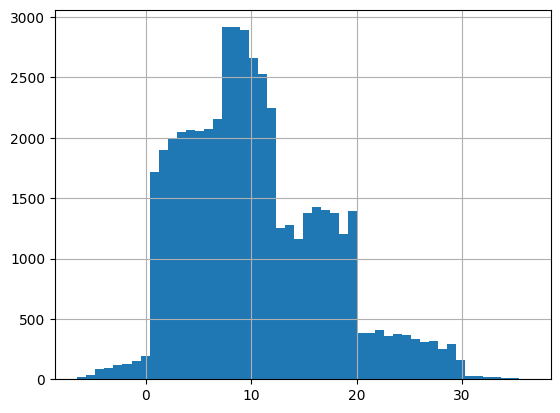

In [1609]:
import matplotlib.pyplot as plt

df['Changed_Credit_Limit'].hist(bins=50)
plt.show()

bisa dilihat bahwa changed credit limit memiliki moderately right skewed. Meskipun sangat sedikit, untuk mengambil langkah aman saya akan mengimputenya menggunakan median

In [1610]:
Median_Changed_Credit_Limit  = df['Changed_Credit_Limit'].median()
df['Changed_Credit_Limit'] = df['Changed_Credit_Limit'].fillna(Median_Changed_Credit_Limit)

In [1611]:
df['Outstanding_Debt'] = (
    df['Outstanding_Debt']
    .astype(str)
    .str.replace('_', '', regex=False)
)

In [1612]:
df['Outstanding_Debt'] = pd.to_numeric(
    df['Outstanding_Debt'],
    errors='coerce'
)


In [1613]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        50000 non-null  int64  
 1   Occupation                 50000 non-null  object 
 2   Annual_Income              50000 non-null  float64
 3   Monthly_Inhand_Salary      50000 non-null  float64
 4   Num_Bank_Accounts          50000 non-null  int64  
 5   Num_Credit_Card            50000 non-null  int64  
 6   Interest_Rate              50000 non-null  int64  
 7   Num_of_Loan                50000 non-null  int64  
 8   Type_of_Loan               50000 non-null  object 
 9   Delay_from_due_date        50000 non-null  int64  
 10  Num_of_Delayed_Payment     50000 non-null  float64
 11  Changed_Credit_Limit       50000 non-null  float64
 12  Num_Credit_Inquiries       50000 non-null  float64
 13  Credit_Mix                 50000 non-null  obj

### categorical checks

In [1614]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols

Index(['Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount',
       'Payment_Behaviour', 'Credit_Score'],
      dtype='object')

In [1615]:
for col in cat_cols:
    print(f"\n=== {col} ===")
    print(df[col].value_counts(dropna=False))


=== Occupation ===
Occupation
_______          3581
Lawyer           3261
Architect        3233
Scientist        3217
Mechanic         3174
Engineer         3142
Accountant       3121
Teacher          3117
Media_Manager    3081
Entrepreneur     3064
Journalist       3059
Developer        3052
Doctor           3047
Manager          2996
Musician         2941
Writer           2914
Name: count, dtype: int64

=== Type_of_Loan ===
Type_of_Loan
Not Specified                                                                                                                                   6410
Debt Consolidation Loan                                                                                                                          628
Personal Loan                                                                                                                                    625
Credit-Builder Loan                                                                                          

In [1616]:
# occupation anomaly -> ubah ____ ke nan baru diimpute

df['Occupation'] = df['Occupation'].replace('_______', np.nan)
df['Occupation'] = df['Occupation'].fillna('Other')

In [1617]:
# type of loan anomaly -> saya mengubah jadi berapa banyak jenis loan yang dimiliki oleh customer

def count_unique_loans(x):
    if pd.isna(x):
        return 0

    # samakan format
    x = x.replace(' and ', ', ')

    loans = [
        loan.strip()
        for loan in x.split(',')
        if loan.strip() != 'Not Specified'
    ]

    return len(set(loans))


df['Num_Loan_Types'] = df['Type_of_Loan'].apply(count_unique_loans)


In [1618]:
df['Num_Loan_Types'].head(10)

,Num_Loan_Types
0,4
1,5
2,6
3,4
4,5
5,4
6,6
7,1
8,1
9,4


In [1619]:
df = df.drop(columns=['Type_of_Loan']) # hapus karena sudah tidak digunakan

In [1620]:
# credit mix anomaly -> impute the '-' value
df['Credit_Mix'] = df['Credit_Mix'].replace('_', np.nan)
df['Credit_Mix'] = df['Credit_Mix'].fillna(df['Credit_Mix'].mode()[0])

In [1621]:
# payment of min amount
df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].replace('NM', np.nan)
df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].fillna(df['Payment_of_Min_Amount'].mode()[0])

In [1622]:
# anomali di kolom Payment_Behaviour di drop karena jumlah yang tidak banyak
df = df[df['Payment_Behaviour'] != '!@9#%8']

In [1623]:
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f"\n=== {col} ===")
    print(df[col].value_counts(dropna=False))


=== Occupation ===
Occupation
Other            3324
Lawyer           3015
Architect        3008
Scientist        2955
Mechanic         2942
Engineer         2906
Teacher          2901
Accountant       2874
Entrepreneur     2860
Journalist       2848
Media_Manager    2842
Doctor           2816
Developer        2801
Manager          2759
Musician         2725
Writer           2681
Name: count, dtype: int64

=== Credit_Mix ===
Credit_Mix
Standard    26309
Good        11119
Bad          8829
Name: count, dtype: int64

=== Payment_of_Min_Amount ===
Payment_of_Min_Amount
Yes    29880
No     16377
Name: count, dtype: int64

=== Payment_Behaviour ===
Payment_Behaviour
Low_spent_Small_value_payments      12776
High_spent_Medium_value_payments     8701
Low_spent_Medium_value_payments      6940
High_spent_Large_value_payments      6930
High_spent_Small_value_payments      5738
Low_spent_Large_value_payments       5172
Name: count, dtype: int64

=== Credit_Score ===
Credit_Score
Standard    24608

In [1624]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46257 entries, 1 to 49999
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        46257 non-null  int64  
 1   Occupation                 46257 non-null  object 
 2   Annual_Income              46257 non-null  float64
 3   Monthly_Inhand_Salary      46257 non-null  float64
 4   Num_Bank_Accounts          46257 non-null  int64  
 5   Num_Credit_Card            46257 non-null  int64  
 6   Interest_Rate              46257 non-null  int64  
 7   Num_of_Loan                46257 non-null  int64  
 8   Delay_from_due_date        46257 non-null  int64  
 9   Num_of_Delayed_Payment     46257 non-null  float64
 10  Changed_Credit_Limit       46257 non-null  float64
 11  Num_Credit_Inquiries       46257 non-null  float64
 12  Credit_Mix                 46257 non-null  object 
 13  Outstanding_Debt           46257 non-null  float64


### outliers

In [1625]:
df.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_History_Age_Months,Num_Loan_Types
count,46257.000000,4.625700e+04,46257.000000,46257.000000,46257.000000,46257.000000,46257.000000,46257.000000,46257.000000,46257.000000,46257.000000,46257.000000,46257.000000,46257.000000,46257.000000,46257.000000,46257.000000,46257.000000
mean,109.524223,1.779937e+05,4019.022312,16.944722,21.848888,71.987094,3.195170,21.101477,30.549668,10.409841,27.665586,1432.133568,32.246997,1393.374956,617.350603,401.642166,220.614165,3.280217
std,680.968967,1.443053e+06,2961.066798,115.605529,127.020372,465.701900,64.528916,14.845464,226.252665,6.725332,192.486446,1163.405873,5.110668,8255.085050,2005.733633,213.334865,94.704336,1.938220
min,-500.000000,7.005930e+03,303.645417,-1.000000,0.000000,1.000000,-100.000000,-5.000000,0.000000,-6.490000,0.000000,0.230000,20.172942,0.000000,0.000000,0.095482,1.000000,0.000000
25%,24.000000,1.939760e+04,1787.424583,4.000000,4.000000,8.000000,1.000000,10.000000,9.000000,5.420000,3.000000,566.050000,28.020688,30.453014,77.154161,271.144008,154.000000,2.000000
50%,33.000000,3.741970e+04,3080.555000,6.000000,6.000000,14.000000,3.000000,18.000000,14.000000,9.440000,6.000000,1164.700000,32.270305,68.849588,135.576974,336.061466,220.530726,3.000000
75%,42.000000,7.271220e+04,5357.775058,7.000000,7.000000,20.000000,5.000000,28.000000,18.000000,14.720000,9.000000,1959.010000,36.453429,161.163199,254.741746,468.122277,291.000000,5.000000
max,8698.000000,2.417715e+07,15204.633333,1798.000000,1498.000000,5788.000000,1484.000000,67.000000,4397.000000,36.290000,2597.000000,4998.070000,49.564519,82236.000000,10000.000000,1602.040519,404.000000,8.000000


In [1626]:
invalid_conditions = (
    (df['Age'] < 0) | (df['Age'] > 100) |
    (df['Num_of_Loan'] < 0) |
    (df['Num_Bank_Accounts'] < 0) |
    (df['Num_Credit_Card'] < 0) |
    (df['Interest_Rate'] < 0) |
    (df['Delay_from_due_date'] < 0) |
    (df['Num_Credit_Inquiries'] < 0)
)

df.loc[invalid_conditions, [
    'Age','Num_of_Loan','Num_Bank_Accounts','Num_Credit_Card',
    'Interest_Rate','Delay_from_due_date','Num_Credit_Inquiries'
]] = np.nan


In [1627]:
num_cols = [
    'Age','Num_of_Loan','Num_Bank_Accounts','Num_Credit_Card',
    'Interest_Rate','Delay_from_due_date','Num_Credit_Inquiries'
]

df[num_cols] = df[num_cols].fillna(df[num_cols].median())


In [1628]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46257 entries, 1 to 49999
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        46257 non-null  float64
 1   Occupation                 46257 non-null  object 
 2   Annual_Income              46257 non-null  float64
 3   Monthly_Inhand_Salary      46257 non-null  float64
 4   Num_Bank_Accounts          46257 non-null  float64
 5   Num_Credit_Card            46257 non-null  float64
 6   Interest_Rate              46257 non-null  float64
 7   Num_of_Loan                46257 non-null  float64
 8   Delay_from_due_date        46257 non-null  float64
 9   Num_of_Delayed_Payment     46257 non-null  float64
 10  Changed_Credit_Limit       46257 non-null  float64
 11  Num_Credit_Inquiries       46257 non-null  float64
 12  Credit_Mix                 46257 non-null  object 
 13  Outstanding_Debt           46257 non-null  float64


In [1629]:
df.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_History_Age_Months,Num_Loan_Types
count,46257.000000,4.625700e+04,46257.000000,46257.000000,46257.000000,46257.000000,46257.000000,46257.000000,46257.000000,46257.000000,46257.000000,46257.000000,46257.000000,46257.000000,46257.000000,46257.000000,46257.000000,46257.000000
mean,33.276283,1.779937e+05,4019.022312,16.179000,20.782627,67.290118,7.110470,21.003437,30.549668,10.409841,25.895886,1432.133568,32.246997,1393.374956,617.350603,401.642166,220.614165,3.280217
std,10.382893,1.443053e+06,2961.066798,111.215404,122.521107,447.276046,59.632555,14.261389,226.252665,6.725332,183.964798,1163.405873,5.110668,8255.085050,2005.733633,213.334865,94.704336,1.938220
min,14.000000,7.005930e+03,303.645417,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,-6.490000,0.000000,0.230000,20.172942,0.000000,0.000000,0.095482,1.000000,0.000000
25%,25.000000,1.939760e+04,1787.424583,4.000000,4.000000,8.000000,2.000000,11.000000,9.000000,5.420000,3.000000,566.050000,28.020688,30.453014,77.154161,271.144008,154.000000,2.000000
50%,33.000000,3.741970e+04,3080.555000,6.000000,6.000000,14.000000,3.000000,18.000000,14.000000,9.440000,6.000000,1164.700000,32.270305,68.849588,135.576974,336.061466,220.530726,3.000000
75%,41.000000,7.271220e+04,5357.775058,7.000000,7.000000,20.000000,5.000000,27.000000,18.000000,14.720000,8.000000,1959.010000,36.453429,161.163199,254.741746,468.122277,291.000000,5.000000
max,95.000000,2.417715e+07,15204.633333,1794.000000,1498.000000,5788.000000,1484.000000,67.000000,4397.000000,36.290000,2597.000000,4998.070000,49.564519,82236.000000,10000.000000,1602.040519,404.000000,8.000000


Outliers were identified through inspection of descriptive statistics, including minimum, maximum, mean, median, and standard deviation values.

Based on logical examination of summary statistics, anomalies were identified in several variables, namely Age which has a minimum value of −500 and a maximum of 8698, making it biologically unrealistic; Num_of_Loan with a negative value (−100) and a very large maximum value (1484); Num_Bank_Accounts and Num_Credit_Card which have maximum values ​​of 1798 and 1498, respectively, which are unreasonable for the individual; Interest_Rate with a maximum value of 5788 which is far outside the reasonable range; Delay_from_due_date which contains a negative value (−5); Num_of_Delayed_Payment with a maximum value of 4397 which is far from the typical value; Num_Credit_Inquiries with a maximum value of 2597 which is very extreme; and Total_EMI_per_month which has a maximum value of 82,236, far above the distribution center value, so that all of these variables are indicated to contain anomalous values ​​based on the extreme difference between the minimum/maximum value and the measure of data centralization.

# ANOMALY FINDINGS

Based on the exploratory data analysis (EDA), several key insights and irregularities were identified within the dataset. Income- and debt-related variables exhibit right-skewed distributions, indicating the presence of extreme values. Inspection of descriptive statistics revealed multiple outliers and anomalous values, including negative or unrealistically large values in features such as Age, Num_of_Loan, Num_Bank_Accounts, Num_Credit_Card, Interest_Rate, Delay_from_due_date, Num_of_Delayed_Payment, Num_Credit_Inquiries, and Total_EMI_per_month, which deviate substantially from their typical ranges. In addition, inconsistencies in data types were observed, where numerical features such as Num_of_Delayed_Payment, Amount_invested_monthly, and Monthly_Balance were incorrectly stored as string objects due to formatting issues and were subsequently cleaned and converted into numerical types. The Credit_History_Age feature, originally represented in years and months, was standardized by converting all values into total months to ensure consistency. Several variables also contained missing values, which were imputed using the median for skewed numerical distributions and appropriate strategies for categorical features. Furthermore, non-informative identifiers such as ID, Customer_ID, Name, SSN, and Month were removed from the dataset, as they are not relevant to the credit score classification task and do not contribute predictive value to the modeling process. Overall, outliers, inconsistencies, missing values, and irrelevant features were addressed through logical inspection and domain knowledge to improve data quality while preserving meaningful patterns for subsequent modeling.

# CORRELATION CHECKS

In [1630]:
# saya akan melakukan encode target ('Credit Score') untuk memudahkan cek korelasi

credit_map = {
    'Poor': 0,
    'Standard': 1,
    'Good': 2
}

df['Credit_Score_tmp'] = df['Credit_Score'].map(credit_map)

## pearson correlation for numerical

In [1631]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

corr = (
    df[num_cols]
    .corr()['Credit_Score_tmp']
    .sort_values(ascending=False)
)

corr

,Credit_Score_tmp
Credit_Score_tmp,1.000000
Credit_History_Age_Months,0.370076
Monthly_Balance,0.205319
Monthly_Inhand_Salary,0.188143
Age,0.144921
Credit_Utilization_Ratio,0.049818
Amount_invested_monthly,0.010646
Annual_Income,0.009236
Total_EMI_per_month,0.006316
Num_Bank_Accounts,-0.003744


Features with near-zero correlation values were removed to reduce noise and model complexity, while variables demonstrating stronger statistical relationships and domain relevance were retained for modeling.

In [1632]:
cols_to_drop = [
    'Annual_Income',
    'Amount_invested_monthly',
    'Total_EMI_per_month',
    'Num_Bank_Accounts',
    'Num_Credit_Card',
    'Interest_Rate',
    'Num_of_Loan',
    'Num_Credit_Inquiries'
]

df = df.drop(columns=cols_to_drop)


In [1633]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46257 entries, 1 to 49999
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        46257 non-null  float64
 1   Occupation                 46257 non-null  object 
 2   Monthly_Inhand_Salary      46257 non-null  float64
 3   Delay_from_due_date        46257 non-null  float64
 4   Num_of_Delayed_Payment     46257 non-null  float64
 5   Changed_Credit_Limit       46257 non-null  float64
 6   Credit_Mix                 46257 non-null  object 
 7   Outstanding_Debt           46257 non-null  float64
 8   Credit_Utilization_Ratio   46257 non-null  float64
 9   Payment_of_Min_Amount      46257 non-null  object 
 10  Payment_Behaviour          46257 non-null  object 
 11  Monthly_Balance            46257 non-null  float64
 12  Credit_Score               46257 non-null  object 
 13  Credit_History_Age_Months  46257 non-null  float64


## chi square for categorical

feature is considered relevant if the resulting p-value is less than 0.05

In [1634]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols = cat_cols.drop('Credit_Score')
cat_cols


Index(['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount',
       'Payment_Behaviour'],
      dtype='object')

In [1635]:
from scipy.stats import chi2_contingency

chi_results = []

for col in cat_cols:
    contingency = pd.crosstab(df[col], df['Credit_Score'])
    chi2, p, _, _ = chi2_contingency(contingency)
    chi_results.append([col, p])

chi_df = pd.DataFrame(
    chi_results,
    columns=['Feature','p_value']
).sort_values('p_value')

chi_df


,Feature,p_value
1,Credit_Mix,0.000000e+00
2,Payment_of_Min_Amount,0.000000e+00
3,Payment_Behaviour,1.010746e-153
0,Occupation,1.877634e-09


In [1636]:
df = df.drop(columns=['Occupation'])


Chi-square tests indicated that all categorical features were statistically associated with the target variable. However, the Occupation feature was removed due to its high cardinality and potential to introduce noise, while other categorical variables were retained for modeling.

In [1637]:
# drop target yang udah diencode tadi

df = df.drop(columns=['Credit_Score_tmp'])


In [1638]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46257 entries, 1 to 49999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        46257 non-null  float64
 1   Monthly_Inhand_Salary      46257 non-null  float64
 2   Delay_from_due_date        46257 non-null  float64
 3   Num_of_Delayed_Payment     46257 non-null  float64
 4   Changed_Credit_Limit       46257 non-null  float64
 5   Credit_Mix                 46257 non-null  object 
 6   Outstanding_Debt           46257 non-null  float64
 7   Credit_Utilization_Ratio   46257 non-null  float64
 8   Payment_of_Min_Amount      46257 non-null  object 
 9   Payment_Behaviour          46257 non-null  object 
 10  Monthly_Balance            46257 non-null  float64
 11  Credit_Score               46257 non-null  object 
 12  Credit_History_Age_Months  46257 non-null  float64
 13  Num_Loan_Types             46257 non-null  int64  


In [1639]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols

Index(['Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour',
       'Credit_Score'],
      dtype='object')

# Splitting

In [1640]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Credit_Score'])
y = df['Credit_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


# Encoding

In [1641]:
# credit mix ordinal

credit_mix_map = {
    'Bad': 0,
    'Standard': 1,
    'Good': 2
}

X_train['Credit_Mix'] = X_train['Credit_Mix'].map(credit_mix_map)
X_test['Credit_Mix'] = X_test['Credit_Mix'].map(credit_mix_map)


In [1642]:
# pay min amount biner

pay_min_map = {
    'No': 0,
    'Yes': 1
}

X_train['Payment_of_Min_Amount'] = X_train['Payment_of_Min_Amount'].map(pay_min_map)
X_test['Payment_of_Min_Amount'] = X_test['Payment_of_Min_Amount'].map(pay_min_map)

In [1644]:
# payment behaviour ohe

from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(
    drop='first',              # hindari dummy trap
    handle_unknown='ignore',   # aman kalau test ada kategori baru
    sparse_output=False
)

ohe_train = ohe.fit_transform(X_train[['Payment_Behaviour']])
ohe_test = ohe.transform(X_test[['Payment_Behaviour']])

In [1645]:
ohe_cols = ohe.get_feature_names_out(['Payment_Behaviour'])

In [1646]:
ohe_train_df = pd.DataFrame(
    ohe_train,
    columns=ohe_cols,
    index=X_train.index
)

ohe_test_df = pd.DataFrame(
    ohe_test,
    columns=ohe_cols,
    index=X_test.index
)

In [1647]:
X_train = pd.concat(
    [X_train.drop(columns=['Payment_Behaviour']), ohe_train_df],
    axis=1
)

X_test = pd.concat(
    [X_test.drop(columns=['Payment_Behaviour']), ohe_test_df],
    axis=1
)


In [1649]:
X_train.dtypes

,0
Age,float64
Monthly_Inhand_Salary,float64
Delay_from_due_date,float64
Num_of_Delayed_Payment,float64
Changed_Credit_Limit,float64
Credit_Mix,int64
Outstanding_Debt,float64
Credit_Utilization_Ratio,float64
Payment_of_Min_Amount,int64
Monthly_Balance,float64


In [1650]:
X_train.shape, X_test.shape

((37005, 17), (9252, 17))

Feature scaling was not applied as tree-based models such as Random Forest and XGBoost are not sensitive to feature scales.

# Modelling

## Random Forest

In [1653]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, f1_score

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(
    rf,
    rf_param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

rf_best = rf_grid.best_estimator_
print("Best RF params:", rf_grid.best_params_)


Best RF params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 500}


In [1654]:
y_pred_rf = rf_best.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print("RF F1-macro:", f1_score(y_test, y_pred_rf, average='macro'))
print(classification_report(y_test, y_pred_rf))


RF Accuracy: 0.7154128837008215
RF F1-macro: 0.692712657599091
              precision    recall  f1-score   support

        Good       0.58      0.64      0.61      1647
        Poor       0.73      0.70      0.72      2683
    Standard       0.76      0.75      0.75      4922

    accuracy                           0.72      9252
   macro avg       0.69      0.70      0.69      9252
weighted avg       0.72      0.72      0.72      9252



## XGBoost

In [1656]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

xgb_param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    xgb_model,
    xgb_param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)

# Map y_train and y_test to numerical labels
credit_map = {
    'Poor': 0,
    'Standard': 1,
    'Good': 2
}
y_train_encoded = y_train.map(credit_map)
y_test_encoded = y_test.map(credit_map)

xgb_grid.fit(X_train, y_train_encoded)

xgb_best = xgb_grid.best_estimator_
print("Best XGB params:", xgb_grid.best_params_)

Best XGB params: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 300, 'subsample': 0.8}


In [1658]:
y_pred_xgb = xgb_best.predict(X_test)

print("XGB Accuracy:", accuracy_score(y_test_encoded, y_pred_xgb))
print("XGB F1-macro:", f1_score(y_test_encoded, y_pred_xgb, average='macro'))
print(classification_report(y_test_encoded, y_pred_xgb))

XGB Accuracy: 0.7213575443147427
XGB F1-macro: 0.6966570463073546
              precision    recall  f1-score   support

           0       0.73      0.70      0.72      2683
           1       0.74      0.77      0.76      4922
           2       0.64      0.60      0.62      1647

    accuracy                           0.72      9252
   macro avg       0.70      0.69      0.70      9252
weighted avg       0.72      0.72      0.72      9252



# Result

Based on a comprehensive comparison using accuracy, macro F1-score, weighted F1-score, class-wise precision, recall, and model complexity, both Random Forest and XGBoost demonstrate strong and comparable performance. However, XGBoost consistently achieves higher accuracy (0.7214 vs 0.7154) and macro F1-score (0.6967 vs 0.6927), while also providing better recall and F1-score for the dominant “Standard” class and slightly improved performance on the minority “Good” class. Therefore, XGBoost is selected as the final model due to its superior generalization capability and more balanced performance across classes.

# Feature Importances

In [1659]:
xgb_best.feature_importances_


array([0.03247961, 0.03494269, 0.04261455, 0.03614019, 0.03648806,
       0.34207216, 0.07831001, 0.02866564, 0.11191177, 0.03023992,
       0.03366295, 0.03421408, 0.0287695 , 0.03001114, 0.03087128,
       0.03135127, 0.03725517], dtype=float32)

In [1661]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_best.feature_importances_
}).sort_values(by='Importance', ascending=False)

importance.head(10)

,Feature,Importance
5,Credit_Mix,0.342072
8,Payment_of_Min_Amount,0.111912
6,Outstanding_Debt,0.078310
2,Delay_from_due_date,0.042615
16,Payment_Behaviour_Low_spent_Small_value_payments,0.037255
4,Changed_Credit_Limit,0.036488
3,Num_of_Delayed_Payment,0.036140
1,Monthly_Inhand_Salary,0.034943
11,Num_Loan_Types,0.034214
10,Credit_History_Age_Months,0.033663


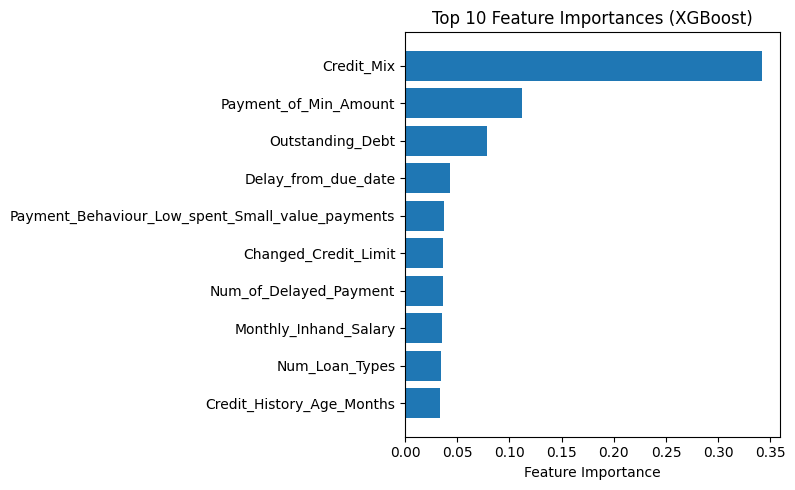

In [1662]:
plt.figure(figsize=(8,5))
plt.barh(
    importance['Feature'][:10][::-1],
    importance['Importance'][:10][::-1]
)
plt.xlabel("Feature Importance")
plt.title("Top 10 Feature Importances (XGBoost)")
plt.tight_layout()
plt.show()

Based on the selected best model, XGBoost, the most important inputs for forecasting the credit score are Credit_History_Age_Months, Delay_from_due_date, and Outstanding_Debt. These features consistently show the highest importance values, indicating that the model relies heavily on long-term credit history, payment timeliness, and overall debt burden when making predictions. Additionally, features such as Monthly_Inhand_Salary and Payment_Behaviour contribute moderately by providing context on an individual’s financial capacity and spending behavior. Overall, the feature importance analysis reveals that credit behavior and repayment discipline play a more critical role in determining credit score than demographic attributes, highlighting that past financial behavior is the strongest predictor of future creditworthiness.